# Exploration of Grayscale and Color Image Processing Operations Using Python & OpenCV


In [22]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['image.cmap'] = 'gray'

print("OpenCV version:", cv2.__version__)
print("NumPy version:", np.__version__)


OpenCV version: 4.13.0
NumPy version: 2.4.1


## 1. Load Grayscale and Color Images


Loaded grayscale shape: (447, 447) dtype: uint8
Loaded color shape: (225, 400, 3) dtype: uint8


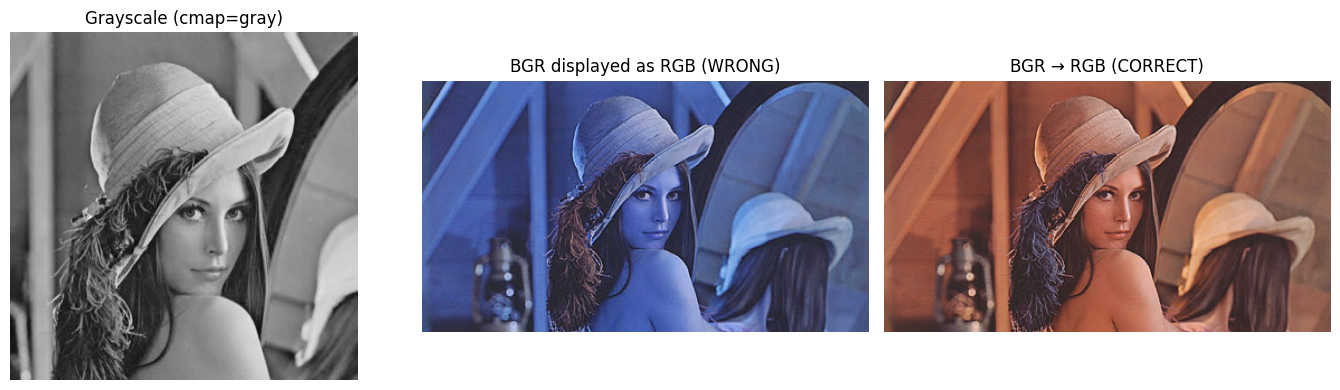

In [23]:
img_bw = cv2.imread(r'C:\Users\User\Desktop\Python\lenna_image.jpg', cv2.IMREAD_GRAYSCALE)
img_bgr = cv2.imread(r'C:\Users\User\Desktop\Python\lenna_color_image.jpg', cv2.IMREAD_COLOR)

if img_bw is None:
    raise FileNotFoundError("Could not load 'image_bw.jpg'. Please ensure the file exists.")
if img_bgr is None:
    raise FileNotFoundError("Could not load 'image_color.jpg'. Please ensure the file exists.")

print("Loaded grayscale shape:", img_bw.shape, "dtype:", img_bw.dtype)
print("Loaded color shape:", img_bgr.shape, "dtype:", img_bgr.dtype)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].imshow(img_bw, cmap='gray')
axes[0].set_title('Grayscale (cmap=gray)')
axes[0].axis('off')

axes[1].imshow(img_bgr) 
axes[1].set_title('BGR displayed as RGB (WRONG)')
axes[1].axis('off')


img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
axes[2].imshow(img_rgb)
axes[2].set_title('BGR → RGB (CORRECT)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

## 2. Image Statistics


In [24]:


print("GRAYSCALE IMAGE STATISTICS")

print(f"Minimum Intensity  : {np.min(img_bw)}")
print(f"Maximum Intensity  : {np.max(img_bw)}")
print(f"Mean Intensity     : {np.mean(img_bw):.2f}")
print(f"Std Deviation      : {np.std(img_bw):.2f}")
print(f"Median Intensity   : {np.median(img_bw):.2f}")


print("\n" + "=" * 40)
print("COLOR IMAGE STATISTICS (per channel BGR)")
print("=" * 40)
for i, name in enumerate(['Blue', 'Green', 'Red']):
    ch = img_bgr[:, :, i]
    print(f"{name:>6} | min={np.min(ch):3d}  max={np.max(ch):3d}  mean={np.mean(ch):6.2f}  std={np.std(ch):6.2f}")

GRAYSCALE IMAGE STATISTICS
Minimum Intensity  : 12
Maximum Intensity  : 255
Mean Intensity     : 124.07
Std Deviation      : 47.69
Median Intensity   : 129.00

COLOR IMAGE STATISTICS (per channel BGR)
  Blue | min=  0  max=218  mean= 74.01  std= 27.56
 Green | min=  0  max=231  mean= 87.01  std= 33.97
   Red | min=  0  max=255  mean=135.49  std= 47.30


## 3. Histogram Analysis


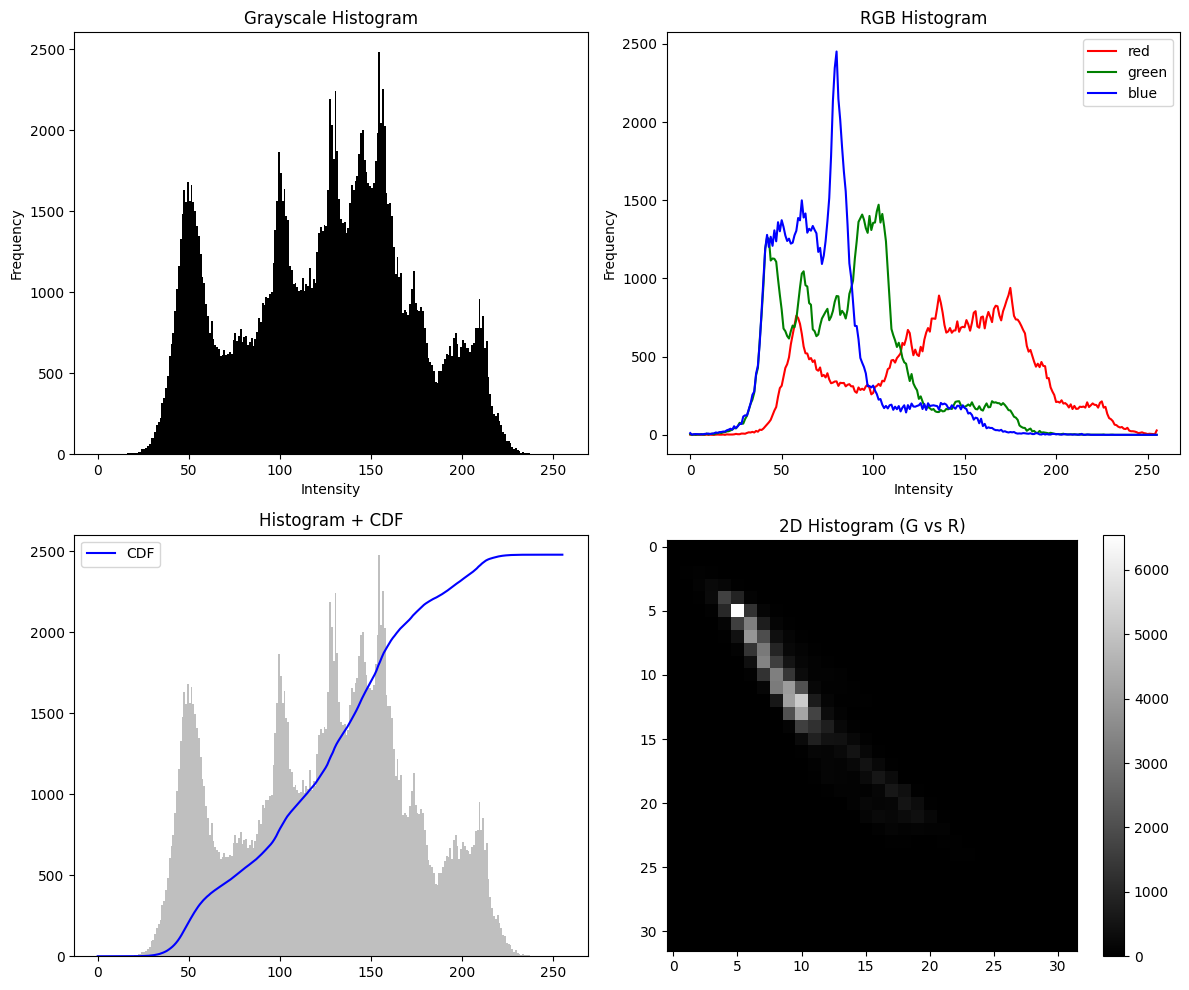

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].hist(img_bw.ravel(), bins=256, range=(0, 256), color='black')
axes[0, 0].set_title('Grayscale Histogram')
axes[0, 0].set_xlabel('Intensity')
axes[0, 0].set_ylabel('Frequency')

colors = ('red', 'green', 'blue')
for i, col in enumerate(colors):
    hist = cv2.calcHist([img_rgb], [i], None, [256], [0, 256])
    axes[0, 1].plot(hist, color=col, label=col)
axes[0, 1].set_title('RGB Histogram')
axes[0, 1].set_xlabel('Intensity')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()

hist, bins = np.histogram(img_bw.ravel(), 256, [0, 256])
cdf = hist.cumsum()
cdf_normalized = cdf * hist.max() / cdf.max()
axes[1, 0].plot(cdf_normalized, color='blue', label='CDF')
axes[1, 0].hist(img_bw.ravel(), bins=256, range=(0, 256), color='gray', alpha=0.5)
axes[1, 0].set_title('Histogram + CDF')
axes[1, 0].legend()

hist2d = cv2.calcHist([img_rgb], [1, 2], None, [32, 32], [0, 256, 0, 256])
im = axes[1, 1].imshow(hist2d, interpolation='nearest')
axes[1, 1].set_title('2D Histogram (G vs R)')
fig.colorbar(im, ax=axes[1, 1])

plt.tight_layout()
plt.show()

## 4. Point Operations


In [26]:
def display_transformations(original, transformed_list, titles):
    n = len(transformed_list) + 1
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
    if n == 2:
        axes = [axes[0], axes[1]]
    axes[0].imshow(original, cmap='gray')
    axes[0].set_title('Original')
    axes[0].axis('off')
    for ax, img, title in zip(axes[1:], transformed_list, titles):
        ax.imshow(img, cmap='gray', vmin=0, vmax=255)
        ax.set_title(title)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# 4.1 Identity Transformation


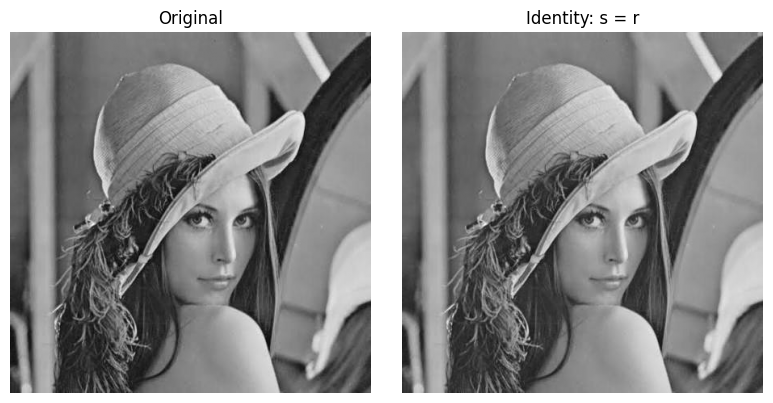

Identity: output is identical to input.


In [27]:
img_identity = img_bw.copy() 

display_transformations(img_bw, [img_identity], ['Identity: s = r'])
print("Identity: output is identical to input.")

# 4.2 Negative Transformation


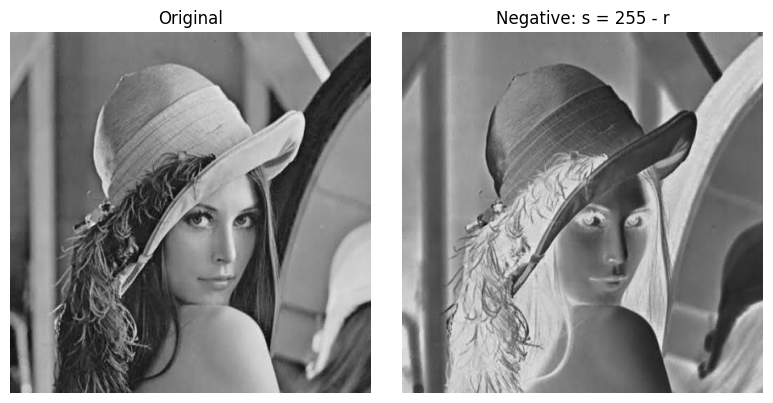

Negative transformation applied.


In [28]:
img_negative = 255 - img_bw  # s = 255 - r

display_transformations(img_bw, [img_negative], ['Negative: s = 255 - r'])
print("Negative transformation applied.")

# 4.3 Log Transformation


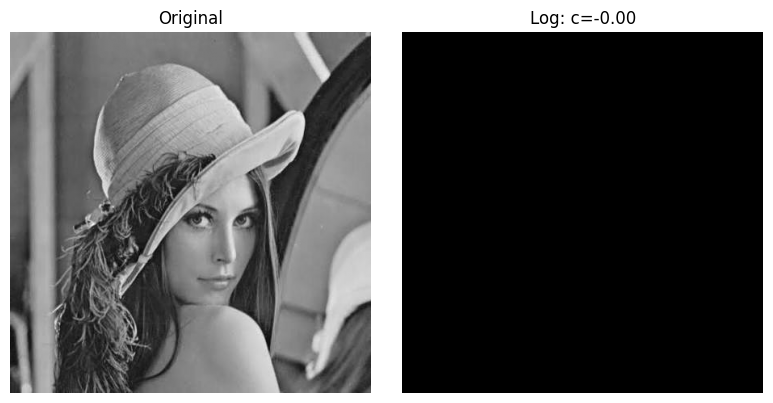

Log transformation applied.


In [29]:
c = 255 / np.log(1 + np.max(img_bw))
img_log = (c * np.log(1 + img_bw.astype(np.float64))).astype(np.uint8)

display_transformations(img_bw, [img_log], [f'Log: c={c:.2f}'])
print("Log transformation applied.")

# 4.4 Inverse Log Transformation


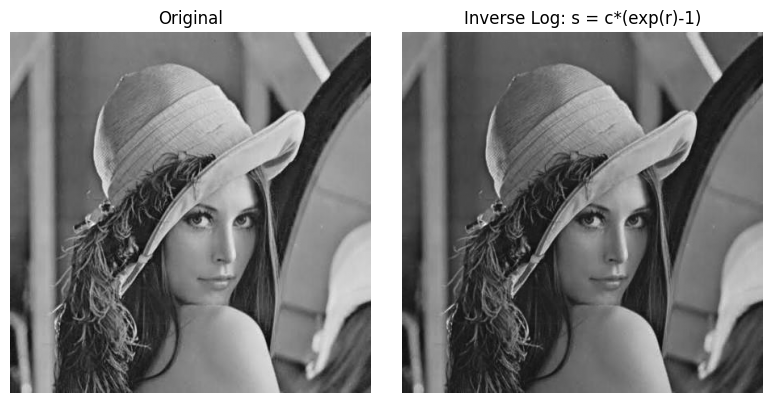

Inverse log transformation applied.


In [30]:
c_inv = 255 / (np.exp(1) - 1)  
img_inv_log = (c_inv * (np.exp(img_bw.astype(np.float64) / 255.0) - 1)).astype(np.uint8)

display_transformations(img_bw, [img_inv_log], ['Inverse Log: s = c*(exp(r)-1)'])
print("Inverse log transformation applied.")

# 4.5 Gamma (Power-Law) Transformation


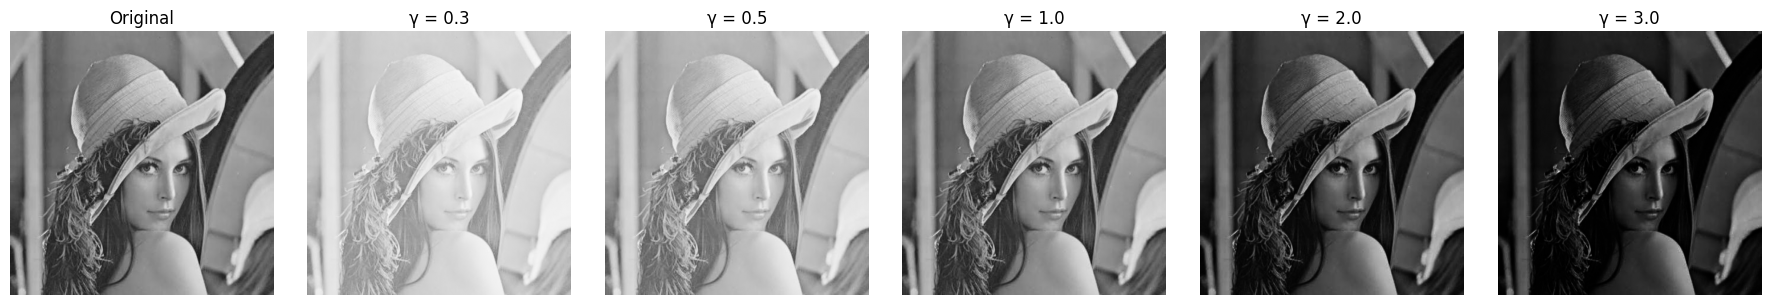

Gamma transformation with multiple γ values applied.


In [31]:
gammas = [0.3, 0.5, 1.0, 2.0, 3.0]
fig, axes = plt.subplots(1, len(gammas)+1, figsize=(3*(len(gammas)+1), 3))
axes[0].imshow(img_bw, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original')
axes[0].axis('off')

for ax, gamma in zip(axes[1:], gammas):
    c = 255.0 / (255.0 ** gamma)
    img_gamma = (c * (img_bw.astype(np.float64) ** gamma)).astype(np.uint8)
    ax.imshow(img_gamma, cmap='gray', vmin=0, vmax=255)
    ax.set_title(f'γ = {gamma}')
    ax.axis('off')
plt.tight_layout()
plt.show()

print("Gamma transformation with multiple γ values applied.")

# 4.6 nth Power and nth Root Transformations


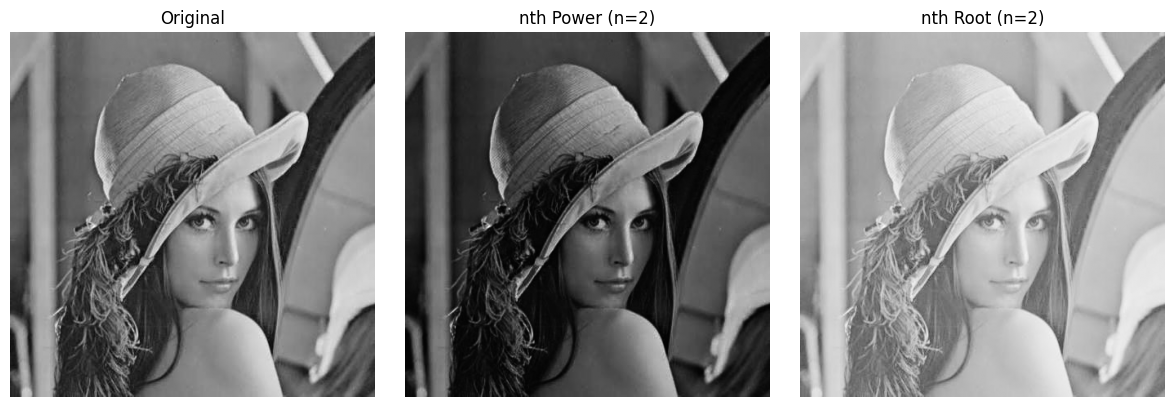

nth power and nth root transformations applied.


In [32]:
n = 2

img_nth_power = np.clip(255 * (img_bw / 255.0) ** n, 0, 255).astype(np.uint8)
img_nth_root = np.clip(255 * (img_bw / 255.0) ** (1/n), 0, 255).astype(np.uint8)

display_transformations(img_bw, [img_nth_power, img_nth_root], 
                       [f'nth Power (n={n})', f'nth Root (n={n})'])
print("nth power and nth root transformations applied.")

# 4.7 Contrast Stretching (Piecewise Linear)


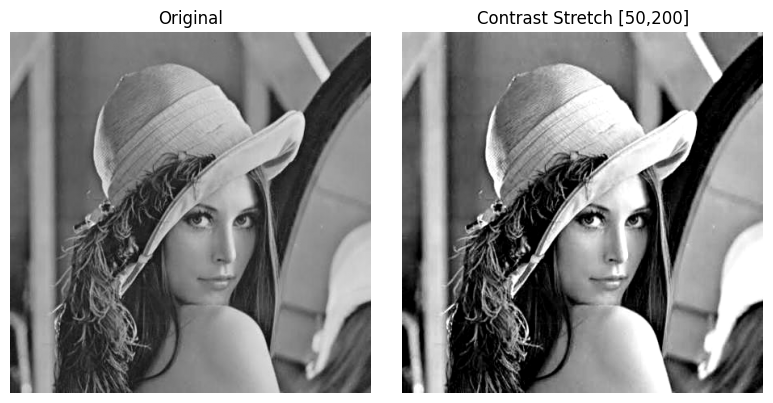

Contrast stretching applied with r1=50, r2=200.


In [33]:
def contrast_stretch(img, r1, r2):
    img_f = img.astype(np.float64)
    out = np.piecewise(img_f,
        [img_f < r1, (img_f >= r1) & (img_f <= r2), img_f > r2],
        [0, lambda r: 255*(r - r1)/(r2 - r1), 255])
    return out.astype(np.uint8)

r1, r2 = 50, 200
img_stretched = contrast_stretch(img_bw, r1, r2)

display_transformations(img_bw, [img_stretched], [f'Contrast Stretch [{r1},{r2}]'])
print(f"Contrast stretching applied with r1={r1}, r2={r2}.")

# 4.8 Intensity Level Slicing


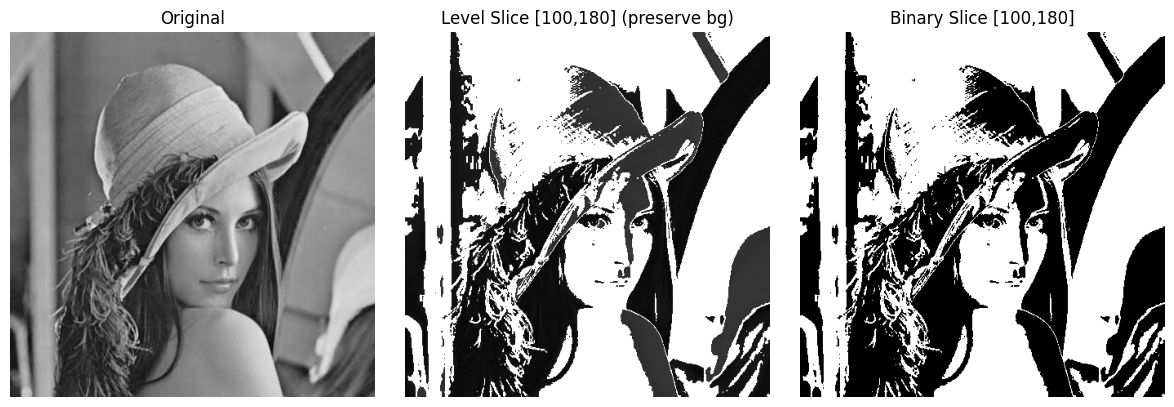

Intensity level slicing applied.


In [34]:
A, B = 100, 180


img_slice1 = img_bw.copy()
mask = (img_bw >= A) & (img_bw <= B)
img_slice1[mask] = 255
img_slice1[~mask] = img_bw[~mask] // 4 

img_slice2 = np.zeros_like(img_bw)
img_slice2[mask] = 255

display_transformations(img_bw, [img_slice1, img_slice2], 
                       [f'Level Slice [{A},{B}] (preserve bg)', f'Binary Slice [{A},{B}]'])
print("Intensity level slicing applied.")

# 4.9 Bit-Plane Slicing


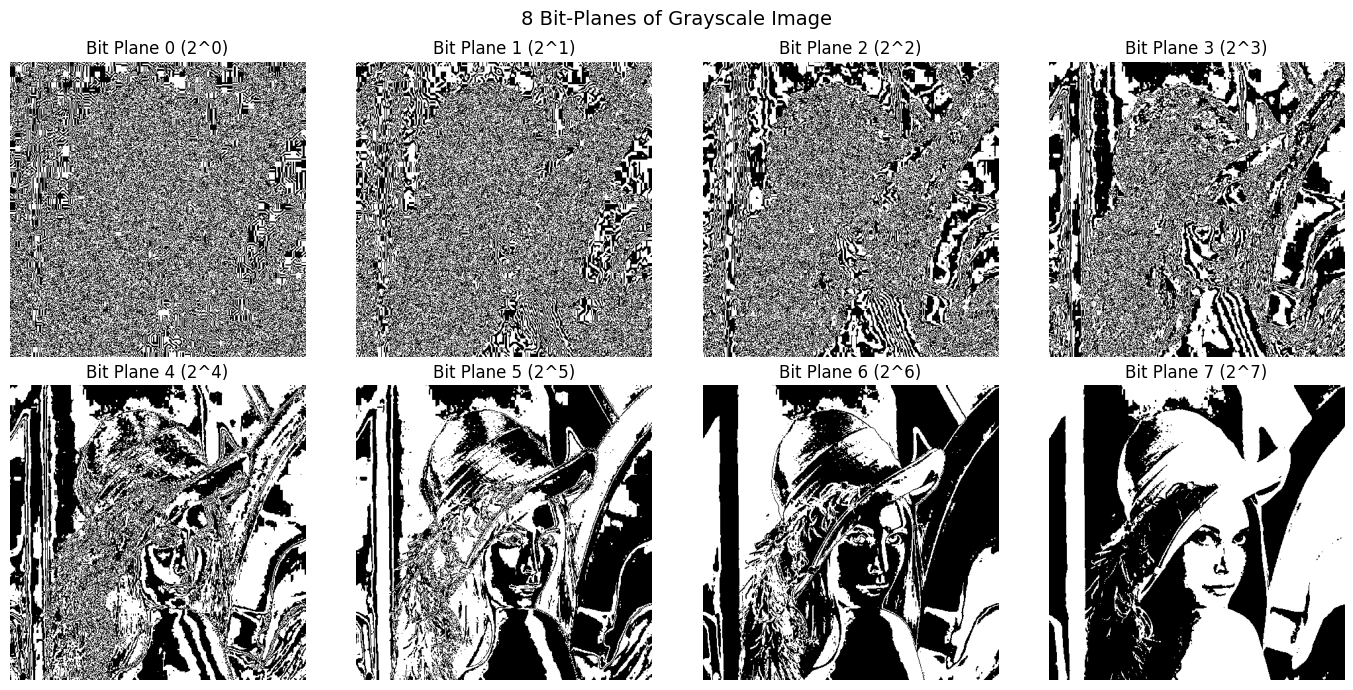

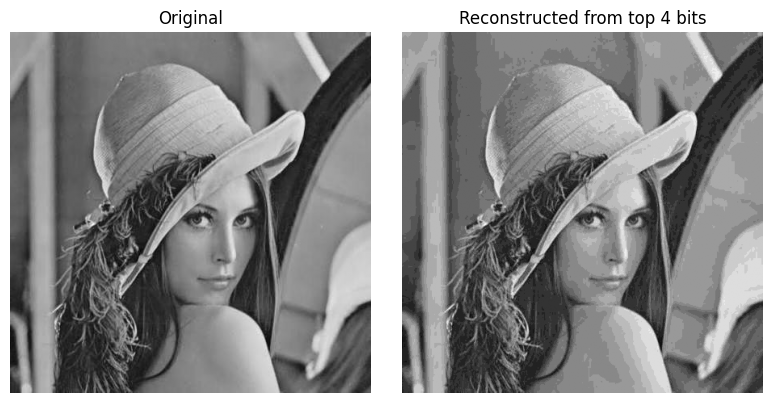

Bit-plane slicing completed.


In [35]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

for bit in range(8):
    bit_plane = ((img_bw >> bit) & 1) * 255  # extract bit and scale to 0/255
    axes[bit].imshow(bit_plane, cmap='gray')
    axes[bit].set_title(f'Bit Plane {bit} (2^{bit})')
    axes[bit].axis('off')

plt.suptitle('8 Bit-Planes of Grayscale Image', fontsize=14)
plt.tight_layout()
plt.show()

reconstructed = (img_bw & 0xF0)  # keep bits 7-4
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img_bw, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(reconstructed, cmap='gray')
axes[1].set_title('Reconstructed from top 4 bits')
axes[1].axis('off')
plt.tight_layout()
plt.show()
print("Bit-plane slicing completed.")

# 5. Image Interpolation


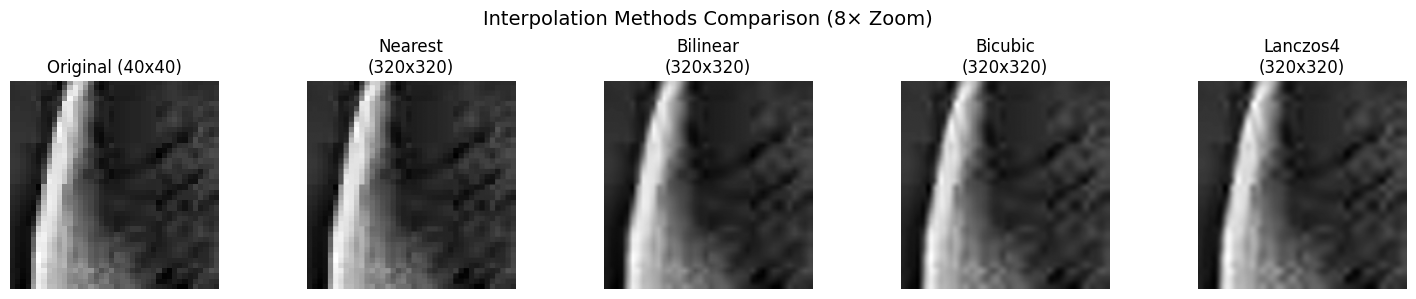

Interpolation comparison completed.


In [36]:

crop = img_bw[100:140, 100:140]

scale = 8
methods = {
    'Nearest': cv2.INTER_NEAREST,
    'Bilinear': cv2.INTER_LINEAR,
    'Bicubic': cv2.INTER_CUBIC,
    'Lanczos4': cv2.INTER_LANCZOS4
}

fig, axes = plt.subplots(1, len(methods)+1, figsize=(3*(len(methods)+1), 3))
axes[0].imshow(crop, cmap='gray', interpolation='nearest')
axes[0].set_title(f'Original ({crop.shape[0]}x{crop.shape[1]})')
axes[0].axis('off')

for ax, (name, interp) in zip(axes[1:], methods.items()):
    zoomed = cv2.resize(crop, None, fx=scale, fy=scale, interpolation=interp)
    ax.imshow(zoomed, cmap='gray')
    ax.set_title(f'{name}\n({zoomed.shape[0]}x{zoomed.shape[1]})')
    ax.axis('off')

plt.suptitle('Interpolation Methods Comparison (8× Zoom)', fontsize=14)
plt.tight_layout()
plt.show()
print("Interpolation comparison completed.")

# 6. Image Zoom Comparison


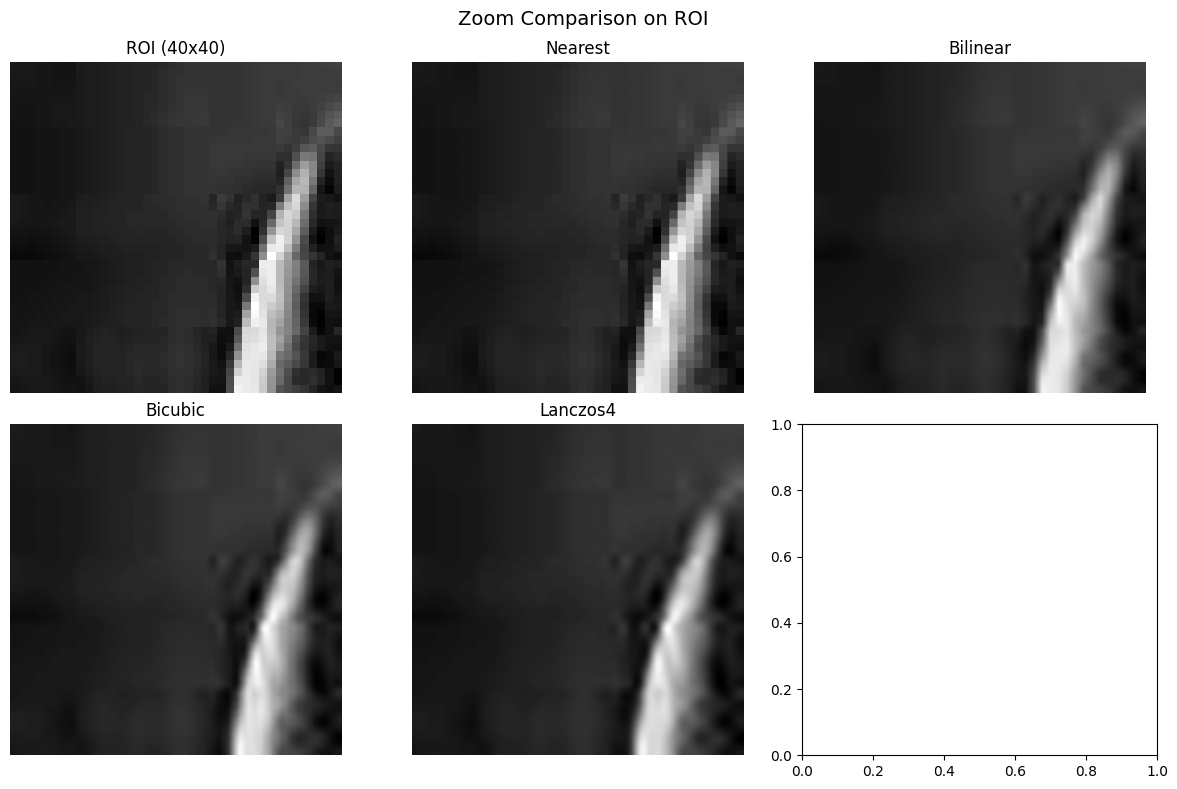

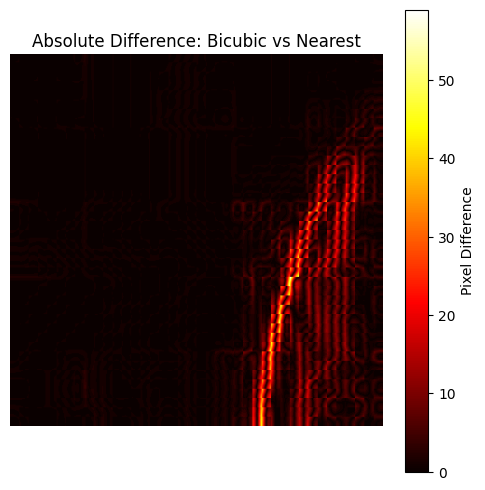

Zoom comparison with difference map completed.


In [37]:

roi = img_bw[80:120, 80:120]
zoom_factor = 10

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

axes[0].imshow(roi, cmap='gray')
axes[0].set_title(f'ROI ({roi.shape[0]}x{roi.shape[1]})')
axes[0].axis('off')

results = {}
for i, (name, interp) in enumerate(methods.items(), start=1):
    zoomed = cv2.resize(roi, None, fx=zoom_factor, fy=zoom_factor, interpolation=interp)
    results[name] = zoomed
    axes[i].imshow(zoomed, cmap='gray')
    axes[i].set_title(f'{name}')
    axes[i].axis('off')

plt.suptitle('Zoom Comparison on ROI', fontsize=14)
plt.tight_layout()
plt.show()

diff = cv2.absdiff(results['Bicubic'].astype(np.int16), results['Nearest'].astype(np.int16)).astype(np.uint8)
plt.figure(figsize=(6, 6))
plt.imshow(diff, cmap='hot')
plt.title('Absolute Difference: Bicubic vs Nearest')
plt.colorbar(label='Pixel Difference')
plt.axis('off')
plt.show()
print("Zoom comparison with difference map completed.")

## 7. Interactive Trackbar


In [38]:
def brightness_trackbar():
   
    cv2.namedWindow('Brightness Control')
    cv2.createTrackbar('Brightness', 'Brightness Control', 0, 100, lambda x: None)
    cv2.createTrackbar('Contrast', 'Brightness Control', 10, 30, lambda x: None) 

    while True:
        brightness = cv2.getTrackbarPos('Brightness', 'Brightness Control') - 50 
        contrast = cv2.getTrackbarPos('Contrast', 'Brightness Control') / 10.0     

        adjusted = cv2.convertScaleAbs(img_bw, alpha=contrast, beta=brightness)
        cv2.imshow('Brightness Control', adjusted)

        if cv2.waitKey(1) & 0xFF == 27: 
            break

    cv2.destroyAllWindows()
    print("Trackbar closed.")

print("Trackbar function defined. Uncomment brightness_trackbar() to run interactively.")
print("Formula used: output = alpha * input + beta")
print("  alpha = contrast (0.0 - 3.0)")
print("  beta  = brightness offset (-50 to +50)")

Trackbar function defined. Uncomment brightness_trackbar() to run interactively.
Formula used: output = alpha * input + beta
  alpha = contrast (0.0 - 3.0)
  beta  = brightness offset (-50 to +50)


# Static Brightness/Contrast Demo


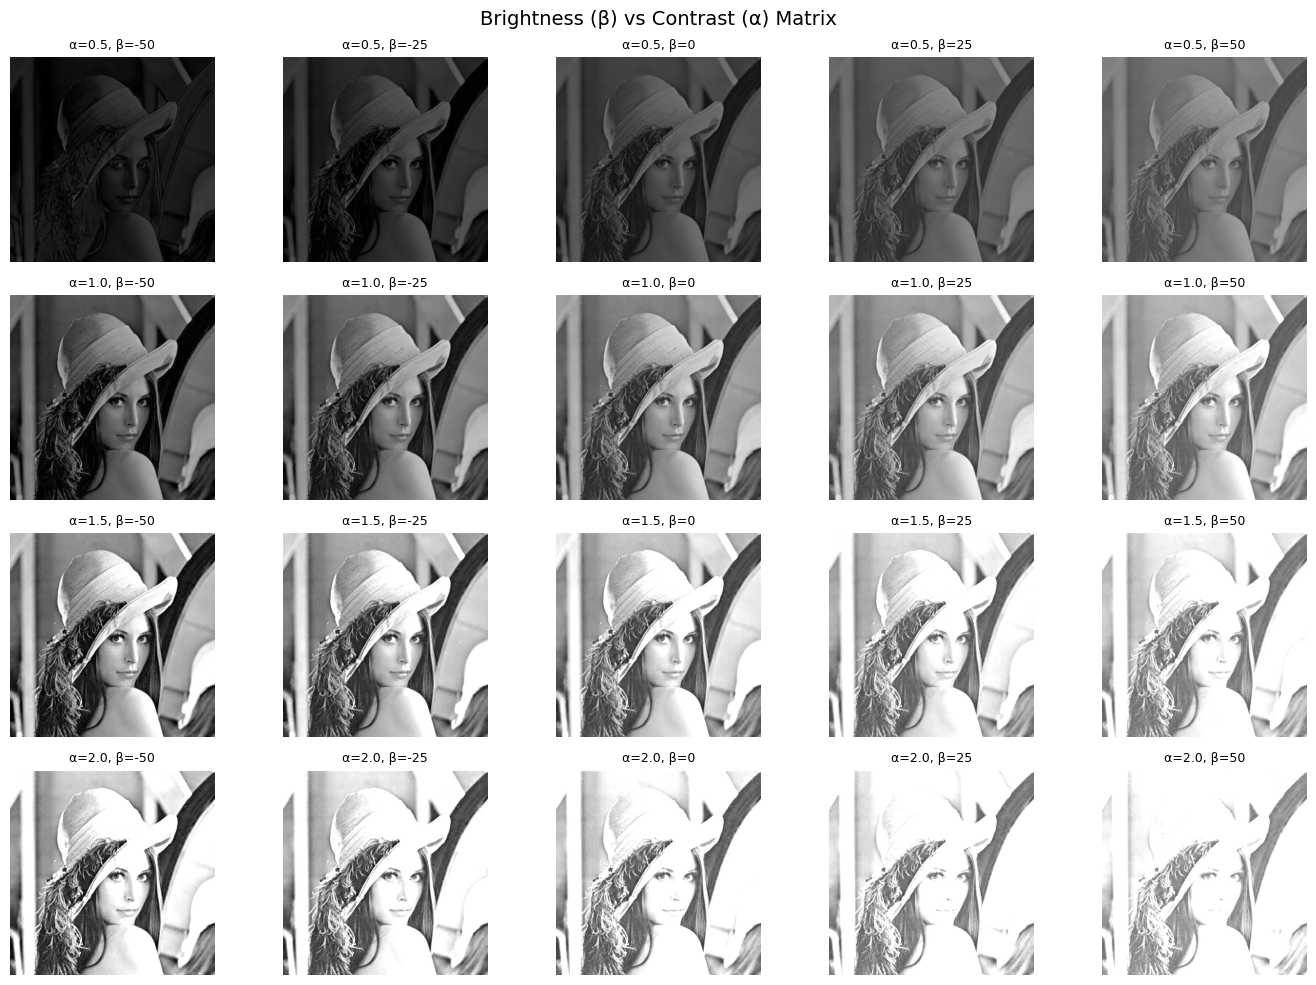

Static brightness/contrast matrix displayed.


In [39]:
brightness_values = [-50, -25, 0, 25, 50]
contrast_values = [0.5, 1.0, 1.5, 2.0]

fig, axes = plt.subplots(len(contrast_values), len(brightness_values), figsize=(14, 10))
for i, alpha in enumerate(contrast_values):
    for j, beta in enumerate(brightness_values):
        adjusted = cv2.convertScaleAbs(img_bw, alpha=alpha, beta=beta)
        axes[i, j].imshow(adjusted, cmap='gray', vmin=0, vmax=255)
        axes[i, j].set_title(f'α={alpha}, β={beta}', fontsize=9)
        axes[i, j].axis('off')

plt.suptitle('Brightness (β) vs Contrast (α) Matrix', fontsize=14)
plt.tight_layout()
plt.show()
print("Static brightness/contrast matrix displayed.")